In [7]:
import time
import numpy as np
import torch

# Neural-GC repo 루트 기준
from models.cmlp import cMLP
from models.cmlp import train_model_ista

# ---------------------------
# 1. 데이터 로드
# ---------------------------
path = "/Users/ipa/workspace/Neural-GC/simulated/causal_dag_4node_signal.npy"
X = np.load(path).astype(np.float32)
X = torch.tensor(X).unsqueeze(0)   # batch 차원 추가

print("X shape:", X.shape)

# ---------------------------
# 2. 하이퍼파라미터
# ---------------------------
p = X.shape[-1]
lag = 5
hidden = [100]
lam = 0.1
lr = 1e-2
max_iter = 2500
check_every = 100

# ---------------------------
# 3. 모델 생성
# ---------------------------
cmlp = cMLP(
    num_series=p,
    lag=lag,
    hidden=hidden,
    activation='relu'
)

# ---------------------------
# 4. 학습 + 시간 측정
# ---------------------------
start_time = time.time()

loss_history = train_model_ista(
    cmlp,
    X,
    lam=lam,
    lr=lr,
    max_iter=max_iter,
    check_every=check_every,
    verbose=1
)

end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTraining time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} min)")

GC = cmlp.GC().cpu().data.numpy()

print("Estimated Granger Causality Matrix:")
print(GC)

X shape: torch.Size([1, 2000, 4])
----------Iter = 100----------
Loss = 4.150175
Variable usage = 100.00%
----------Iter = 200----------
Loss = 3.424834
Variable usage = 100.00%
----------Iter = 300----------
Loss = 2.771673
Variable usage = 100.00%
----------Iter = 400----------
Loss = 2.197960
Variable usage = 100.00%
----------Iter = 500----------
Loss = 1.728051
Variable usage = 100.00%
----------Iter = 600----------
Loss = 1.399253
Variable usage = 100.00%
----------Iter = 700----------
Loss = 1.174927
Variable usage = 100.00%
----------Iter = 800----------
Loss = 1.013104
Variable usage = 100.00%
----------Iter = 900----------
Loss = 0.908479
Variable usage = 100.00%
----------Iter = 1000----------
Loss = 0.823192
Variable usage = 100.00%
----------Iter = 1100----------
Loss = 0.763599
Variable usage = 100.00%
----------Iter = 1200----------
Loss = 0.726140
Variable usage = 100.00%
----------Iter = 1300----------
Loss = 0.693307
Variable usage = 100.00%
----------Iter = 1400-----

In [8]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 저장 폴더
# ---------------------------
save_dir = "/Users/ipa/workspace/Neural-GC/results_4_nodes(iter2500)"
os.makedirs(save_dir, exist_ok=True)

# ---------------------------
# 1) 모델 저장
# ---------------------------
torch.save(cmlp.state_dict(), os.path.join(save_dir, "cmlp_model.pt"))

# ---------------------------
# 1-1) 학습 시간 저장
# ---------------------------
np.save(os.path.join(save_dir, "elapsed_time.npy"), np.array(elapsed_time))

# loss_history가 있으면 같이 저장
if loss_history is not None:
    try:
        loss_history_np = np.array([float(x) for x in loss_history])
        np.save(os.path.join(save_dir, "loss_history.npy"), loss_history_np)
    except:
        pass

# ---------------------------
# 2) Binary GC matrix 추출
# ---------------------------
GC = cmlp.GC().cpu().data.numpy()
np.save(os.path.join(save_dir, "gc_binary.npy"), GC)

# ---------------------------
# 3) Continuous strength matrix 추출
# ---------------------------
def extract_gc_strength(cmlp):
    strengths = []

    for net in cmlp.networks:
        first_conv = None
        for module in net.modules():
            if isinstance(module, torch.nn.Conv1d):
                first_conv = module
                break

        if first_conv is None:
            raise RuntimeError("Conv1d layer를 찾지 못했습니다.")

        w = first_conv.weight.detach().cpu()
        s = torch.norm(w, dim=(0, 2))
        strengths.append(s.numpy())

    strengths = np.stack(strengths, axis=0)
    return strengths

GC_strength = extract_gc_strength(cmlp)
np.save(os.path.join(save_dir, "gc_strength.npy"), GC_strength)

print("Binary GC matrix:")
print(GC)

print("\nContinuous GC strength matrix:")
print(np.round(GC_strength, 4))

print(f"\nSaved training time: {elapsed_time:.2f} sec")

Binary GC matrix:
[[1 0 0 0]
 [0 1 0 0]
 [1 0 1 0]
 [1 1 1 1]]

Continuous GC strength matrix:
[[0.2825 0.     0.     0.    ]
 [0.     0.2926 0.     0.    ]
 [0.3133 0.     0.1684 0.    ]
 [0.0009 0.321  0.5215 0.2533]]

Saved training time: 12.14 sec


Saved Binary GC matrix:
[[1 0 0 0]
 [0 1 0 0]
 [1 0 1 0]
 [1 1 1 1]]

Saved Continuous GC strength matrix:
[[0.2825 0.     0.     0.    ]
 [0.     0.2926 0.     0.    ]
 [0.3133 0.     0.1684 0.    ]
 [0.0009 0.321  0.5215 0.2533]]

Training time: 12.14 sec (0.20 min)


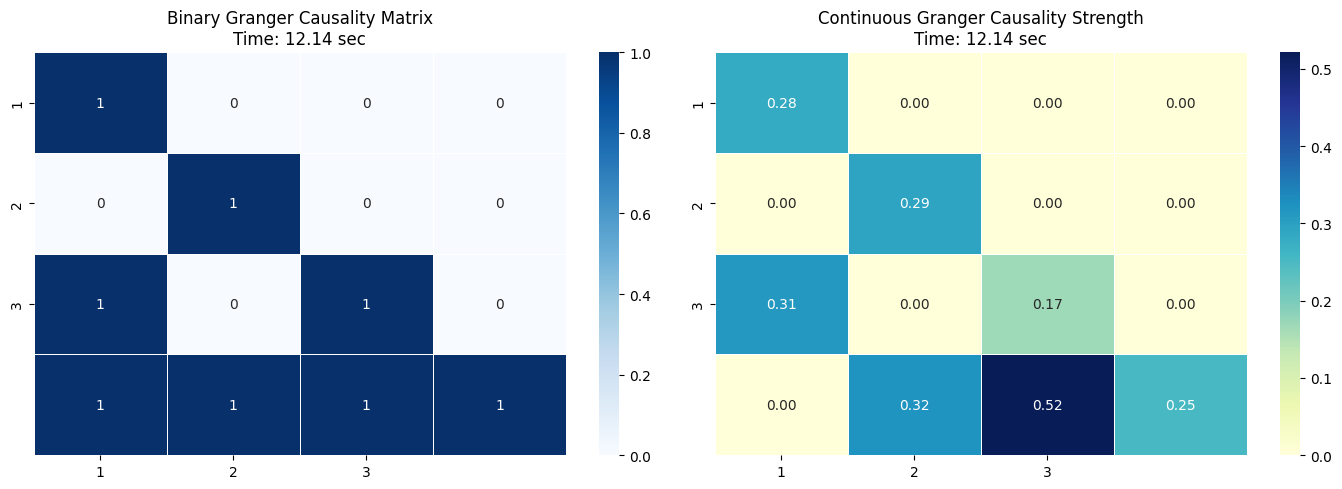

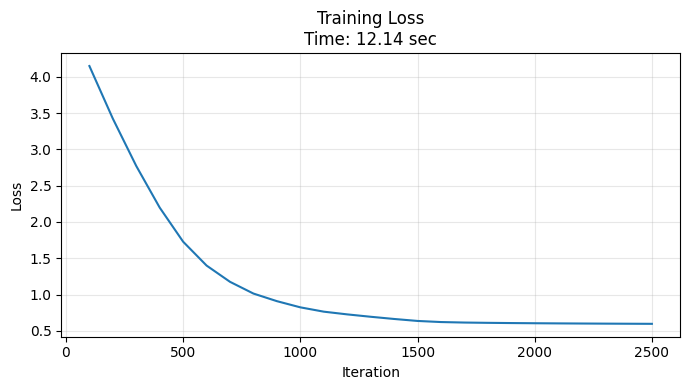

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

save_dir = "/Users/ipa/workspace/Neural-GC/results_4_nodes(iter2500)"

GC = np.load(f"{save_dir}/gc_binary.npy")
GC_strength = np.load(f"{save_dir}/gc_strength.npy")
elapsed_time = np.load(f"{save_dir}/elapsed_time.npy")

print("Saved Binary GC matrix:")
print(GC)

print("\nSaved Continuous GC strength matrix:")
print(np.round(GC_strength, 4))

print(f"\nTraining time: {float(elapsed_time):.2f} sec ({float(elapsed_time)/60:.2f} min)")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(
    GC,
    annot=True,
    cmap="Blues",
    fmt=".0f",
    linewidths=.5,
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)
plt.title(f"Binary Granger Causality Matrix\nTime: {float(elapsed_time):.2f} sec")

plt.subplot(1, 2, 2)
sns.heatmap(
    GC_strength,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=.5,
    xticklabels=[1, 2, 3],
    yticklabels=[1, 2, 3]
)
plt.title(f"Continuous Granger Causality Strength\nTime: {float(elapsed_time):.2f} sec")

plt.tight_layout()
plt.show()

# ---------------------------
# loss plot
# ---------------------------
loss_path = f"{save_dir}/loss_history.npy"

if os.path.exists(loss_path):
    loss_history = np.load(loss_path)

    # iteration 생성 (100, 200, 300, ...)
    check_every = 100
    iterations = np.arange(1, len(loss_history) + 1) * check_every

    plt.figure(figsize=(7, 4))
    plt.plot(iterations, loss_history)   # ✅ marker 제거

    plt.title(f"Training Loss\nTime: {float(elapsed_time):.2f} sec")
    plt.xlabel("Iteration")              # ✅ 변경
    plt.ylabel("Loss")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("loss_history.npy가 저장되지 않았습니다. 현재 train_model_ista가 loss history를 반환하지 않는 버전일 수 있습니다.")